![banner-pdi](https://user-images.githubusercontent.com/58775072/141189378-b5df3287-e8c0-48a1-ad11-825ba317463b.png)

## Universidade Federal de Campina Grande (UFCG)
## Centro de Engenharia Elétrica e Informática (CEEI) 
## Disciplina: Int. ao Processamento de Imagem Digital e Visão Computacional
## Professora: Luciana Ribeiro Veloso
## Aluno(a): Keviny Ryan Menezes Dantas

## Observações
***

1. Os arquivos de laboratório devem ser salvos seguindo o seguinte padrão: `lab-x-nome-sobrenome.ipynb`.
2. Não esqueça de colocar o seu nome no cabeçalho acima.
3. Não altere a ordem das células e realize as implementações somente nos campos específicados.  
4. Ao longo do laboratório será solicitado perguntas teóricas relativas aos assuntos das aulas da disciplina e implementações de código utilizando a linguagem de programação Python. 
5. As células de implementação com código serão indicadas pelos seguintes comentários: `# IMPLEMENTE O SEU CÓDIGO AQUI`.
6. Para editar uma célula de texto, basta clicar duas vezes com o cursos do mouse para editar, e `Ctrl + Enter` para finalizar a edição. 
7. Para rodar as células com os códigos desenvolvidos, digite `Ctrl + Enter` ou clique em `Run` no menu do Jupyter.
8. Dúvidas, problemas de execução de código ou dificuldades com a linguagem de programação Python devem ser feitas durante as aulas de laboratório, encaminhadas para o grupo de WhatsApp da turma ou fórum do PVAE da disciplina.
9. Os laboratórios devem ser enviados nos campos especificados pelo PVAE. ATENTE-SE AOS PRAZOS DE ENTREGA!

# <span style='color:red'>Laboratório 6: Redes Neurais Artificiais</span>
***

### Importação dos Pacotes

In [20]:
import os                                                 # operational system para manipulação de arquivos.
import cv2                                                # openCV para manipulação de imagens.
import numpy as np                                        # numpy para manipulação de matrizes e arrays.
import matplotlib.pyplot as plt                           # pyplot para plotagem de gráficos e imagens.
from sklearn.model_selection import train_test_split      # função para particionamento dos dados
from tensorflow.keras.models import Sequential            # classe de modelos sequenciais para construir as redes neurais.
from tensorflow.keras.layers import Dense, Input, Dropout # camada de neurônios densamente conectados.
from tensorflow.keras.optimizers import SGD               # otimizador "Descida do Gradiente com Momento".
from tensorflow.keras.datasets import boston_housing      # dataset utilizado nesse experimento.

### Banco de Dados
* Vamos utilizar um banco de dados do catálogo de datasets do Keras, que é disponibilizado como uma função pronta;

* Cada instância do banco de dados corresponde a um conjunto de 13 valores referentes a características de subúrbios de Boston na década de 1970, a exemplo de taxa de crimes, imposto sobre propriedade, etc;

* Esses valores serão utilizados para calcular o valor mediano das residências no respectivo subúrbio em um problema de regressão, de modo que iremos mapear um vetor de entrada com 13 valores em um vetor de saída com 1 único elemento;

* O banco de dados contém 506 valores divididos em 404 instâncias de treino e 102 de teste;

* Uma descrição mais detalhada dos valores de entrada pode ser vista em http://lib.stat.cmu.edu/datasets/boston, onde os valores são descritos na ordem que aparecem;

### Organização do banco de dados

* Comumente os dados utilizados no treinamento de modelos de inteligência artificial reservam a primeira dimensão para controlar a amostra e espalham o tipo de dado utilizado nas demais dimensões do tensor. 


* Nesse caso, os nossos dados são vetores de características unidimensionais (1D), de modo que são organizados em tensores bidimensionais (2D) com formato: **dados.shape = (amostras, características)**
    * O i-ésimo exemplo pode ser acessado a partir de: **exemplo = dados[i]**
    * A j-ésima característica dos exemplos pode ser acessada a partir de: **caracteristica = dados[:, j]**
    * Porções do tensor podem ser acessadas utilizando fatiamento, por exemplo:
        * primeiros_5_exemplos = dados[:5]
        * caracteristicas_9a13 = dados[8:13]
        

* Lembrem-se que a contagem de índices em Python começa em 0 e só é inclusiva no primeiro elemento:
    * **:5** produz os índices **0, 1, 2, 3, 4** 
    * **8:13** produz os índices **8, 9, 10, 11, 12** 
        

* O banco de dados pode ser carregado utilizando:
    * **(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()**
    * train_data é um tensor com as entradas do conjunto de treino;
    * test_data é um tensor com as entradas do conjunto de teste;
    * train_targets é um tensor com os gabaritos do conjunto de treino;
    * test_targets é um tensor com os gabaritos do conjunto de teste;

## <span style='color:blue'>Questão 1: [Valor da Questão: 2.0][Taxa de acerto: x.x]</span>

* (a) O código abaixo carrega o banco de dados, acesse alguns exemplos de treinamento e de teste e veja suas dimensões.
    * Use índices entre **[0, 404]** para os dados de treino e entre **[0, 102]** para os de teste.

* (b) Verifique as dimensões e as faixas de valores de cada característica nos vetores de entrada dos conjuntos de treino e de teste. A faixa de valores das características são semelhantes? E os dados de treino e de teste?**</span>
    * Encontre os valores mínimo/máximo além da média **(np.mean)** e da variância **(np.var)** de cada uma das 13 características.
    * Sugestão: leia sobre o parâmetro "axis" na documentação das funções **np.min**, **np.max** e **np.mean**.
* (c) Verifique as dimensões e as faixas de valores dos gabaritos dos conjuntos de treino e de teste. Os valores encontrados são semelhantes?

In [21]:
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

In [22]:
# IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 1 - letra (a)

TreinoA = train_data
TesteA = test_data
GabtreinoA = train_targets
GabtestA = test_targets

print("Dimensão dos Dados para Treinamento: ", TreinoA.shape)
print("Dimensão dos Dados para Teste: ", TesteA.shape)
print("Dimensão dos rótulos dos Dados para Treinamento: ", GabtreinoA.shape)
print("Dimensão dos rótulos dos Dados para Teste: ", GabtestA.shape)

print("\nExemplo de dados Dados de entrada: \n" , TreinoA[0])
print("\nExemplo de dados Dados de entrada: ", GabtreinoA[0])


Dimensão dos Dados para Treinamento:  (404, 13)
Dimensão dos Dados para Teste:  (102, 13)
Dimensão dos rótulos dos Dados para Treinamento:  (404,)
Dimensão dos rótulos dos Dados para Teste:  (102,)

Exemplo de dados Dados de entrada: 
 [  1.23247   0.        8.14      0.        0.538     6.142    91.7
   3.9769    4.      307.       21.      396.9      18.72   ]

Exemplo de dados Dados de entrada:  15.2


|**Características dos Dados de Entrada**|**Descrição**|
|:-:|:-|
|**CRIM**|     <span style='color:red'>per capita crime rate by town</span>|
|**ZN**|       <span style='color:red'>proportion of residential land zoned for lots over 25,000 sq.ft.</span>|
|**INDUS**|    <span style='color:red'>proportion of non-retail business acres per town</span>|
|**CHAS**|     <span style='color:red'>Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)</span>|
|**NOX**|      <span style='color:red'>nitric oxides concentration (parts per 10 million)</span>|
|**RM**|       <span style='color:red'>average number of rooms per dwelling</span>|
|**AGE**|      <span style='color:red'>proportion of owner-occupied units built prior to 1940</span>|
|**DIS**|      <span style='color:red'>weighted distances to five Boston employment centres</span>|
|**RAD**|      <span style='color:red'>index of accessibility to radial highways</span>|
|**TAX**|      <span style='color:red'>full-value property-tax rate per \$10,000</span>|
|**PTRATIO**|  <span style='color:red'>pupil-teacher ratio by town</span>|
|**B**|        <span style='color:red'>$1000(B_k - 0.63)^2$ where Bk is the proportion of blacks by town</span>|
|**LSTAT**|    <span style='color:red'>\% lower status of the population</span>|

|**Características dos Dados de Saída**|**Descrição**|
|:-:|:-|
|**MEDV**|     <span style='color:red'>Median value of owner-occupied homes in \$1000's</span>|

In [23]:
# IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 1 - letra (b)

Treino = train_data
Teste = test_data

print("Dados de Treinamento!")
print("Dimensão dos rótulos dos Dados para Treinamento: ", Treino.shape)
print("\nMenor valor do Tensor de Treinamento: \n", (np.min(Treino, axis = 0)))
print("\nMaior valor do Tensor de Treinamento: \n", (np.max(Treino, axis = 0)))
print("\nValor Médio do Tensor de Treinamento: \n", (np.mean(Treino, axis = 0)))
print("\nValor de Variação do Tensor de Treinamento: \n", (np.var(Treino, axis = 0)))

print("\n===========================================\n")

print("Dados  de Teste!")
print("Dimensão dos rótulos dos Dados para Teste: ", Teste.shape)
print("\nMenor valor do Tensor de Teste: \n", (np.min(Teste, axis = 0)))
print("\nMaior valor do Tensor de Teste: \n", (np.max(Teste, axis = 0)))
print("\nValor Médio do Tensor de Teste: \n", (np.mean(Teste, axis = 0)))
print("\nValor de Variação do Tensor de Teste: \n", (np.var(Teste, axis = 0)))

Dados de Treinamento!
Dimensão dos rótulos dos Dados para Treinamento:  (404, 13)

Menor valor do Tensor de Treinamento: 
 [6.3200e-03 0.0000e+00 4.6000e-01 0.0000e+00 3.8500e-01 3.5610e+00
 2.9000e+00 1.1296e+00 1.0000e+00 1.8800e+02 1.2600e+01 3.2000e-01
 1.7300e+00]

Maior valor do Tensor de Treinamento: 
 [ 88.9762 100.      27.74     1.       0.871    8.725  100.      10.7103
  24.     711.      22.     396.9     37.97  ]

Valor Médio do Tensor de Treinamento: 
 [3.74511057e+00 1.14801980e+01 1.11044307e+01 6.18811881e-02
 5.57355941e-01 6.26708168e+00 6.90106436e+01 3.74027079e+00
 9.44059406e+00 4.05898515e+02 1.84759901e+01 3.54783168e+02
 1.27408168e+01]

Valor de Variação do Tensor de Treinamento: 
 [8.51798073e+01 5.63505796e+02 4.62790747e+01 5.80519067e-02
 1.37236180e-02 5.02551441e-01 7.78748377e+02 4.11156931e+00
 7.54741937e+01 2.76119724e+04 4.82969580e+00 8.83498510e+03
 5.24981521e+01]


Dados  de Teste!
Dimensão dos rótulos dos Dados para Teste:  (102, 13)

Menor v

In [24]:
# IMPLEMENTE SEU CÓDIGO AQUI -QUESTÃO 1 - letra (c)


Gabtrain = train_targets
Gabtest = test_targets

print("Dados de Gabarito de Treinamento!")
print("Dimensão dos rótulos dos Dados para Treinamento: ", Gabtrain.shape)
print("Menor valor do Gabarito de Treinamento:", (np.min(Gabtrain, axis = 0)))
print("\nMaior valor do Gabarito de Treinamento:", (np.max(Gabtrain, axis = 0)))
print("\nValor Médio do Gabarito de Treinamento:", (np.mean(Gabtrain, axis = 0)))
print("\nValor de Variação do Gabarito de Treinamento:", (np.var(Gabtrain, axis = 0)))

print("\n===========================================\n")

print("Dados de Gabarito de Teste!")
print("Dimensão dos rótulos dos Dados para Teste: ", Gabtest.shape)
print("Menor valor do Gabarito de Teste:", (np.min(Gabtest, axis = 0)))
print("\nMaior valor do Gabarito de Teste:", (np.max(Gabtest, axis = 0)))
print("\nValor Médio do Gabarito de Teste:", (np.mean(Gabtest, axis = 0)))
print("\nValor de Variação do Gabarito de Teste:", (np.var(Gabtest, axis = 0)))



Dados de Gabarito de Treinamento!
Dimensão dos rótulos dos Dados para Treinamento:  (404,)
Menor valor do Gabarito de Treinamento: 5.0

Maior valor do Gabarito de Treinamento: 50.0

Valor Médio do Gabarito de Treinamento: 22.395049504950492

Valor de Variação do Gabarito de Treinamento: 84.62225272032155


Dados de Gabarito de Teste!
Dimensão dos rótulos dos Dados para Teste:  (102,)
Menor valor do Gabarito de Teste: 5.6

Maior valor do Gabarito de Teste: 50.0

Valor Médio do Gabarito de Teste: 23.07843137254902

Valor de Variação do Gabarito de Teste: 83.24384851980008


## <span style='color:green'>Respostas da Questão 1:</span>

* (a) Não contém uma pergunta escrita, apenas o pedido para treinamentos e gabaritos, demonstrado de forma efetiva no código, dando entrada saída e alguns paramêtros dos treinamentos!
* (b) Ao averiguar todos os pontos pedidos para ambos os conjuntos vemos que existe uma discrepância no resultado encontrado entre eles.
* (c) Já na parte dos gabaritos diferentemente das de tensor percebemos que existe uma semelhança entre os resultados, valores que se aproximam em todos os pontos como Menor valor que a diferença entre 1 e outro gabarito é de apenas 0.6, o de maior valor conseguimos encontrar um valor igual para ambos, de média e vaiância a uma pequena diferença nos resultados encontrados!.

### Pre-processamento dos dados

* Dados cujas características assumem diferentes faixas de valores muitas vezes são problemáticos para o aprendizado dos modelos e podem reduzir a velocidade de convergência ou até mesmo limitar as capacidades do modelo final.

* Nesse sentido, uma prática comum é a normalização dos dados antes do treinamento, que geralmente é feito por característica em forma da subtração da média e divisão pelo desvio padrão, o que faz com que os dados resultantes tenham média 0 e variância 1.

* Um ponto muito importante é que a normalização deve ser feita partir dos mesmos valores em todos os conjuntos, ou seja, os dados são normalizados segundo informações do conjunto de treino.

* Na prática não temos como calcular a média e variância real, mas se os dados de treino são significativos os seus valores são suficientes.

In [25]:
# Calcula a média do conjunto de treino
mean = train_data.mean(axis = 0)
# Calcula o desvio padrão do conjunto de treino
std = train_data.std(axis = 0)
# Normaliza os dados de treino
train_data -= mean
train_data /= std
# Normaliza os dados de teste
test_data -= mean
test_data /= std

## <span style='color:blue'>Questão 2: [Valor da Questão: 1.0][Taxa de acerto: x.x]</span>

* Repita o item b da primeira questão para os dados normalizados. O que se observa quantos aos valores de média e variância para os dados de treino e teste? Comente a sua interpretação sobre as diferenças observadas.

In [26]:
# IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 2

Treino = train_data
Teste = test_data

print("Dados de Treinamento!")
print("Dimensão dos rótulos dos Dados para Treinamento: ", Treino.shape)
print("\nMenor valor do Tensor de Treinamento: \n", (np.min(Treino, axis = 0)))
print("\nMaior valor do Tensor de Treinamento: \n", (np.max(Treino, axis = 0)))
print("\nValor Médio do Tensor de Treinamento: \n", (np.mean(Treino, axis = 0)))
print("\nValor de Variação do Tensor de Treinamento: \n", (np.var(Treino, axis = 0)))

print("\n==================================================================\n")

print("Dados  de Teste!")
print("Dimensão dos rótulos dos Dados para Teste: ", Teste.shape)
print("\nMenor valor do Tensor de Teste: \n", (np.min(Teste, axis = 0)))
print("\nMaior valor do Tensor de Teste: \n", (np.max(Teste, axis = 0)))
print("\nValor Médio do Tensor de Teste: \n", (np.mean(Teste, axis = 0)))
print("\nValor de Variação do Tensor de Teste: \n", (np.var(Teste, axis = 0)))

Dados de Treinamento!
Dimensão dos rótulos dos Dados para Treinamento:  (404, 13)

Menor valor do Tensor de Treinamento: 
 [-0.40510053 -0.48361547 -1.56469648 -0.25683275 -1.47126853 -3.81725032
 -2.36904226 -1.28750316 -0.97156928 -1.31131055 -2.67375227 -3.77110135
 -1.51966384]

Maior valor do Tensor de Treinamento: 
 [9.23484718 3.72899018 2.44537425 3.89358447 2.67733525 3.46718635
 1.11048828 3.43740568 1.67588577 1.83609694 1.60353052 0.44807713
 3.48201936]

Valor Médio do Tensor de Treinamento: 
 [-1.01541438e-16  1.09923072e-17  1.74337992e-15 -1.26686340e-16
 -5.25377321e-15  6.41414864e-15  2.98441140e-16  4.94653823e-16
  1.12671149e-17 -1.98136337e-16  2.36686358e-14  5.95679996e-15
  6.13920356e-16]

Valor de Variação do Tensor de Treinamento: 
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Dados  de Teste!
Dimensão dos rótulos dos Dados para Teste:  (102, 13)

Menor valor do Tensor de Teste: 
 [-0.40436483 -0.48361547 -1.45297897 -0.25683275 -1.41151498 -1.95664382
 -2.25

## <span style='color:green'>Resposta da Questão 2:</span>

* Com a normalização do código realizado advinda dos dados de treinamento era esperado que houvesse a média sendo zerada e a variação sendo padronizada em 1 como é explicado acima da questão 2, na parte de processamento, o que por algum motivo ocorreu apenas para a variação, porém creio que era para ter ocorrido nos dois.

Agora vamos criar uma partição de validação a partir do conjunto de treino para realizar uma validação cruzada. Vamos utilizar a função **train_test_split**, que separa dados e os seus respectivos gabaritos segundo uma fração especificada.

In [27]:
# fração escolhida para separar o mesmo número de instâncias do conjunto de testes
data_frac = test_data.shape[0] / train_data.shape[0]

# criação do conjunto de validação
train_data, val_data, train_targets, val_targets = train_test_split(train_data,             # dados de treino
                                                                    train_targets,          # gabaritos de treino
                                                                    test_size = data_frac,  # proporção de dados p/ validação
                                                                    random_state = 42)      # semente de geração

print("Treino:", train_data.shape, train_targets.shape)
print("Validação:", val_data.shape, val_targets.shape)

Treino: (302, 13) (302,)
Validação: (102, 13) (102,)


### Construindo o modelo

Para construir o modelo usaremos a classe **Sequential**, que possibilita a construção de modelos sequenciais de forma bastante simples.
* A construção do modelo é feita a partir do seu instanciamento como objeto da classe seguido de chamadas à função **add()** para adicionar camadas.
* Como estamos construindo apenas Redes Neurais Artificiais por enquanto, vamos utilizar apenas as camadas **Dense** e **Input**.
    * A camada Input cria a entrada da rede com **Input(shape = None )**
        * shape corresponde ao formato do tensor de entrada, no nosso caso será o número de características do nosso banco de dados (13);
    * A camada Dense pode ser chamada com **Dense(n_unidades, activation = 'linear' )**
        * n_unidades corresponde ao número de neurônios da camada;
        * activation corresponde à função de ativação utilizada na camada;
* Algumas funções de ativação disponíveis são:
    * "linear"
    * "relu"
    * "sigmoid"
    * "softmax"
    * "tanh"


* Mais informações sobre a camada dense podem ser vistas em **https://keras.io/api/layers/core_layers/dense/**
* Mais informações sobre as ativações disponíveis podem ser vistas em **https://keras.io/api/layers/activations/**

## <span style='color:blue'>Questão 3: [Valor da Questão: 2.0][Taxa de acerto: x.x]</span>

* (a) A função abaixo constroi um modelo de rede neural e utiliza a função summary() para apresentar um resumo das informações da rede neural produzida. Comente o que faz cada linha do código.
    * (opcional) Modifique parâmetros como o número de unidades de cada camada e/ou o formato do tensor de entrada e/ou o número de saídas.
* (b) Explique como o número de parâmetros de cada camada é calculado.
* (c) Nesse caso utilizamos uma saída com ativação linear. Qual seria a desvantagem de utilizar esse tipo de ativação nas demais camadas?

In [28]:
# COMENTE AS LINHAS DE CÓDIGO AQUI --> QUESTÃO 3 -letra (a)
def build_model( n_inputs, n_outputs ):#Define uma função para construir um modelo ao qual n_inputs conta a quantd de caracter
    '''construção do modelo de rede neural convolucional'''
    
    rede = Sequential()#Cria um modelo de sequencia
    rede.add( Dense(units = 64, activation = "relu", input_shape = (n_inputs,)))
    #Responsável por adcionar camadas com a função Dense, usando 64 como número de campadas, usando a ativação Relu e a contagem
    # de caracteres do BD
    
    rede.add(Dense(units = 64, activation = "relu"))
    #Aplica o Dense com 64 neuronios definido por camada e também a ativação pelo o Relu
    
    rede.add(Dense(units = n_outputs ))
    #Função Dense adicionada sem um número padrão e a função de Nsaídas.
    return rede#retorna os resultados obtido

model = build_model(13, 1)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                896       
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 5,121
Trainable params: 5,121
Non-trainable params: 0
_________________________________________________________________


## <span style='color:green'>Respostas da Questão 3:</span>

* (b) Calculamos efetuando uma multiplicação do valor de entrada pelo o peso do neurônio que corresponde a locação de entrada, tendo uma interatividade com bias_regularizer para passar que seja percorrido e passado para outra camada.
* (c) O que me aparenta ser um problema é através do uso linear para estruturas mais complexas, pois ao efetuar o uso dela existe a permanência do gradiente como padrão, sendo assim não permitindo uma possível melhora do erro, gerando uma possível permanência de um erro não desejado.

Após a construção do modelo ele deve ser compilado antes que os parâmetros sejam treinados. Isso é feito utilizando a função **compile**:

* **model.compile( optimizer = opt, loss = fperdas, metrics = [] )** 
    * O optimizer é o algoritmo otimizador utilizado no lugar da descida do gradiente, o Keras oferece diversas opções;
        * Para treinar a partir da descida do gradiente utilizaremos o SGD (descida do gradiente com momento), mas setaremos esse parâmetro para 0.
        * **opt = SGD( learning_rate = taxa_de_aprendizagem, momentum = 0 )**
    * A função de perdas pode ser definida a partir do parâmetro loss, como este é um problema de regressão utilizaremos o erro médio quadrático: 
        * **loss = "mse"**
    * Podemos passar uma lista de métricas a serem computadas durante o treinamento, nesse caso utilizaremos o erro médio absoluto:
        * **metrics = ["mae"]**
        * Note que estamos passando uma lista com uma única métrica, mas outras poderiam ser adicionadas à lista.
         
         

* Algoritmos otimizadores populares são o Adam (**https://keras.io/api/optimizers/adam/**) e o RMSprop(**https://keras.io/api/optimizers/rmsprop/**)
* Mais informações sobre os otimizadores disponíveis podem ser vistas em **https://keras.io/api/optimizers/**
* Mais informações sobre as funções de perdas disponíveis podem ser vistas em **https://keras.io/api/losses/**
* Mais informações sobre as métricas disponíveis podem ser vistas em **https://keras.io/api/metrics/**



In [29]:
model = build_model(13, 1)
model.compile( optimizer = SGD(learning_rate = 0.001, momentum = 0.0), loss = "mse", metrics = ["mae"] )
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                896       
                                                                 
 dense_4 (Dense)             (None, 64)                4160      
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 5,121
Trainable params: 5,121
Non-trainable params: 0
_________________________________________________________________


### Treinando o modelo

O treinamento é realizado a partir da função **fit**, que recebe dados de treino e de validação além de hiperparâmetros como o número de épocas e o tamanho dos lotes de dados (batchsize).

* **hist = model.fit(x = None, y = None, epochs = 1, batchsize = None, validation_data = None, verbose = "auto")**
    * x corresponde aos dados de treino;
    * y corresponde aos gabaritos de treino;
    * epochs corresponde ao número de épocas de treinamento;
    * batchsize corresponde ao tamanho dos lotes entregues à rede de cada vez;
    * validation_data corresponde a uma tupla ( val_data, val_targets ) com os dados de validação;
    * verbose indica como a função deve reportar os resultados:
        * 0: modo silencioso, nenhum retorno em formato de texto;
        * 1: retorno a cada época e barra de progresso;
        * 2: retorno a cada época sem barra de progresso;
    * hist é um dicionário de retorno com os valores de loss e das métricas computadas para treino e validação;

In [30]:
hist = model.fit(x = train_data, y = train_targets, epochs = 100, 
                 batch_size = 1, validation_data = ( val_data, val_targets ), 
                 verbose = 1)

Epoch 1/100
302/302 [==============================] - 1s 1ms/step - loss: 67.9102 - mae: 5.6018 - val_loss: 63.0508 - val_mae: 5.8490
Epoch 2/100
302/302 [==============================] - 0s 777us/step - loss: 29.3932 - mae: 3.6236 - val_loss: 21.2410 - val_mae: 3.5531
Epoch 3/100
302/302 [==============================] - 0s 862us/step - loss: 24.3606 - mae: 3.5120 - val_loss: 17.9711 - val_mae: 3.4010
Epoch 4/100
302/302 [==============================] - 0s 763us/step - loss: 17.8857 - mae: 3.1637 - val_loss: 11.7308 - val_mae: 2.5937
Epoch 5/100
302/302 [==============================] - 0s 778us/step - loss: 28.6020 - mae: 3.6802 - val_loss: 13.7400 - val_mae: 2.8561
Epoch 6/100
302/302 [==============================] - 0s 848us/step - loss: 14.8432 - mae: 2.8122 - val_loss: 16.2540 - val_mae: 3.1598
Epoch 7/100
302/302 [==============================] - 0s 778us/step - loss: 27.8945 - mae: 3.7493 - val_loss: 13.8835 - val_mae: 2.7088
Epoch 8/100
302/302 [======================

Epoch 61/100
302/302 [==============================] - 0s 792us/step - loss: 8.9049 - mae: 2.0321 - val_loss: 16.2832 - val_mae: 2.6159
Epoch 62/100
302/302 [==============================] - 0s 790us/step - loss: 4.7862 - mae: 1.5949 - val_loss: 11.4764 - val_mae: 2.3521
Epoch 63/100
302/302 [==============================] - 0s 787us/step - loss: 5.0209 - mae: 1.6280 - val_loss: 24.3277 - val_mae: 2.9374
Epoch 64/100
302/302 [==============================] - 0s 849us/step - loss: 10.3909 - mae: 2.1857 - val_loss: 10.3023 - val_mae: 2.2532
Epoch 65/100
302/302 [==============================] - 0s 726us/step - loss: 5.5857 - mae: 1.7117 - val_loss: 9.5482 - val_mae: 2.1880
Epoch 66/100
302/302 [==============================] - 0s 731us/step - loss: 7.4574 - mae: 1.9628 - val_loss: 13.6924 - val_mae: 2.6441
Epoch 67/100
302/302 [==============================] - 0s 718us/step - loss: 6.2616 - mae: 1.8283 - val_loss: 10.6404 - val_mae: 2.2732
Epoch 68/100
302/302 [===================

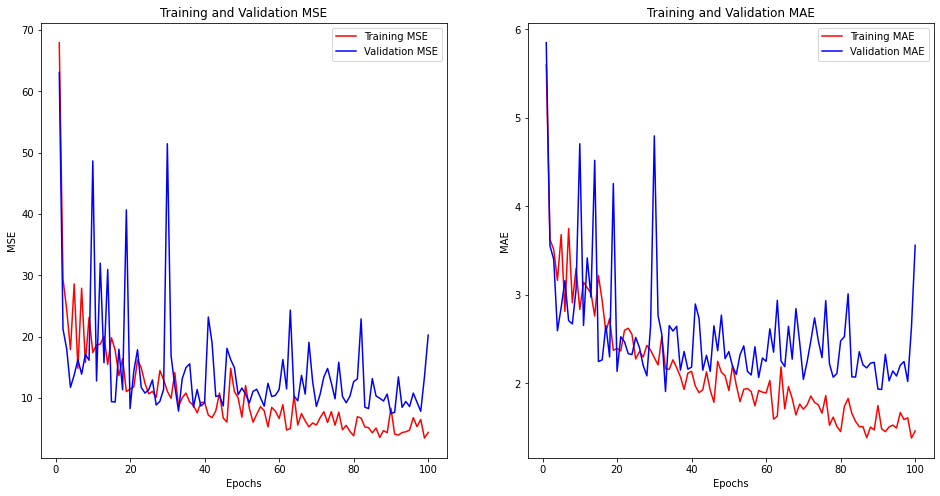

In [32]:
# plotando os resultados obtidos
fig, axes = plt.subplots(1, 2, squeeze = False, figsize = (16,8))

history_dict = hist.history

# loss - MSE
train_loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

# epochs
epochs = range(1, len(train_loss_values) + 1)

# metrica - MAE
train_mae_values = history_dict["mae"]
val_mae_values = history_dict["val_mae"]

ax = axes.flat[0]
ax.plot(epochs, train_loss_values, "r", label = "Training MSE")
ax.plot(epochs, val_loss_values, "b", label = "Validation MSE")
ax.set_title("Training and Validation MSE")
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE")
ax.legend()

ax = axes.flat[1]
ax.plot(epochs, train_mae_values, "r", label = "Training MAE")
ax.plot(epochs, val_mae_values, "b", label = "Validation MAE")
ax.set_title("Training and Validation MAE")
ax.set_xlabel("Epochs")
ax.set_ylabel("MAE")
ax.legend()

## <span style='color:blue'>Questão 4: [Valor da Questão: 2.0][Taxa de acerto: x.x]</span>

* Comente os resultados obtidos nos gráficos acima. Houve overfitting? Se sim, o que pode ser feito para melhorar a qualidade do modelo?

## <span style='color:green'>Respostas da Questão 4:</span>

* Pela a definição do que é Overfitting, basicamente é quando o modelo se adequar tão bem a um banco de dados que está sendo treinado, porém em uma ampliação de dados ele não vai tão bem, pois não aprendeu a diferenciar e basicamente a decorar as diferenças dos dados já trabalhados, ao averiguarmos em uma análise particular creio que não ocrreu no caso em questão, mas que olhando as médias em questão elas não tão favoráveis como gostaríamos apesar de está funcionando bem, o que pode ser melhorado através de aplicação de recursos como a regularização 

## <span style='color:blue'>Questão 5: [Valor da Questão: 2.0][Taxa de acerto: x.x]</span>

* Modifique hiperparâmetros do modelo como o número de camadas, as funções de ativação, o número de épocas utilizadas e o tamanho dos lotes. Comente os resultados obtidos a partir das mudanças realizadas. Utilize várias células para dividir as etapas de construção dos modelos.

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 32)                448       
                                                                 
 dense_19 (Dense)            (None, 32)                1056      
                                                                 
 dense_20 (Dense)            (None, 1)                 33        
                                                                 
Total params: 1,537
Trainable params: 1,537
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
302/302 [==============================] - 0s 978us/step - loss: 75.0748 - mae: 6.0877 - val_loss: 43.4839 - val_mae: 5.7530
Epoch 2/100
302/302 [==============================] - 0s 694us/step - loss: 30.2575 - mae: 4.0414 - val_loss: 38.8933 - val_mae: 4.1608
Epoch 3/100
302/302 [=====================

Epoch 55/100
302/302 [==============================] - 0s 711us/step - loss: 7.6292 - mae: 1.9789 - val_loss: 11.1489 - val_mae: 2.3361
Epoch 56/100
302/302 [==============================] - 0s 698us/step - loss: 6.6649 - mae: 1.8603 - val_loss: 10.3637 - val_mae: 2.4018
Epoch 57/100
302/302 [==============================] - 0s 762us/step - loss: 4.5876 - mae: 1.6476 - val_loss: 11.5984 - val_mae: 2.3304
Epoch 58/100
302/302 [==============================] - 0s 796us/step - loss: 6.3545 - mae: 1.8242 - val_loss: 12.4493 - val_mae: 2.4300
Epoch 59/100
302/302 [==============================] - 0s 831us/step - loss: 5.1507 - mae: 1.7092 - val_loss: 11.7282 - val_mae: 2.3409
Epoch 60/100
302/302 [==============================] - 0s 847us/step - loss: 5.1747 - mae: 1.6923 - val_loss: 14.3208 - val_mae: 2.4906
Epoch 61/100
302/302 [==============================] - 0s 719us/step - loss: 6.4918 - mae: 1.7979 - val_loss: 14.5077 - val_mae: 2.5699
Epoch 62/100
302/302 [===================

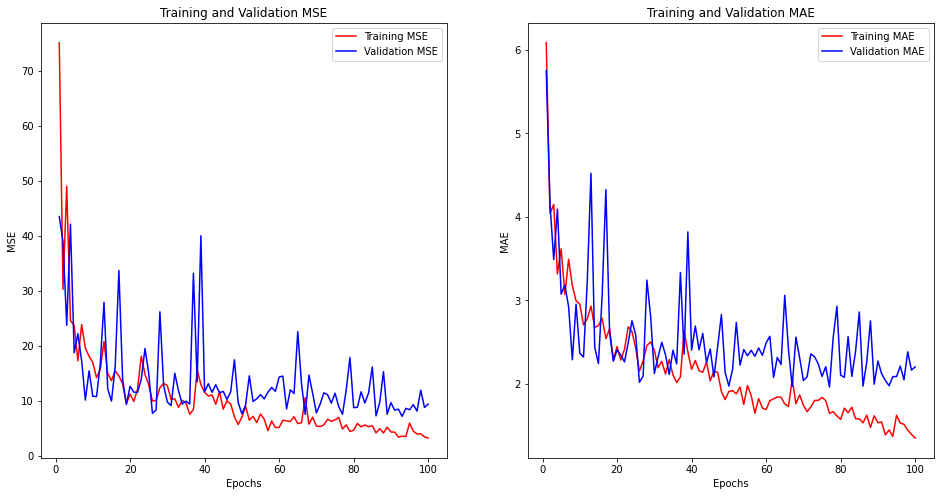

In [39]:
# IMPLEMENTE SEUS MODELOS AQUI --> QUESTÃO 5 (use várias células)

def build_model( n_inputs, n_outputs ):#Define uma função para construir um modelo ao qual n_inputs conta a quantd de caracter
    '''construção do modelo de rede neural convolucional'''
    
    rede = Sequential()#Cria um modelo de sequencia
    rede.add( Dense(units = 32, activation = "relu", input_shape = (n_inputs,)))
    #Responsável por adcionar camadas com a função Dense, usando 64 como número de campadas, usando a ativação Relu e a contagem
    # de caracteres do BD
    
    rede.add(Dense(units = 32, activation = "relu"))
    #Aplica o Dense com 32 neuronios definido por camada e também a ativação pelo o Relu
    
    rede.add(Dense(units = n_outputs ))
    #Função Dense adicionada sem um número padrão e a função de Nsaídas.
    return rede#retorna os resultados obtido
model = build_model(13, 1)
model.compile( optimizer = SGD(learning_rate = 0.001, momentum = 0.0), loss = "mse", metrics = ["mae"] )
model.summary()

hist = model.fit(x = train_data, y = train_targets, epochs = 100, 
                 batch_size = 1, validation_data = ( val_data, val_targets ), 
                 verbose = 1)

# plotando os resultados obtidos
fig, axes = plt.subplots(1, 2, squeeze = False, figsize = (16,8))

history_dict = hist.history

# loss - MSE
train_loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

# epochs
epochs = range(1, len(train_loss_values) + 1)

# metrica - MAE
train_mae_values = history_dict["mae"]
val_mae_values = history_dict["val_mae"]

ax = axes.flat[0]
ax.plot(epochs, train_loss_values, "r", label = "Training MSE")
ax.plot(epochs, val_loss_values, "b", label = "Validation MSE")
ax.set_title("Training and Validation MSE")
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE")
ax.legend()

ax = axes.flat[1]
ax.plot(epochs, train_mae_values, "r", label = "Training MAE")
ax.plot(epochs, val_mae_values, "b", label = "Validation MAE")
ax.set_title("Training and Validation MAE")
ax.set_xlabel("Epochs")
ax.set_ylabel("MAE")
ax.legend()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 128)               1792      
                                                                 
 dense_22 (Dense)            (None, 128)               16512     
                                                                 
 dense_23 (Dense)            (None, 1)                 129       
                                                                 
Total params: 18,433
Trainable params: 18,433
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
302/302 [==============================] - 0s 992us/step - loss: 77.9010 - mae: 6.3077 - val_loss: 12.3831 - val_mae: 2.5782
Epoch 2/100
302/302 [==============================] - 0s 742us/step - loss: 25.1884 - mae: 3.5571 - val_loss: 55.9803 - val_mae: 5.0977
Epoch 3/100
302/302 [===================

Epoch 55/100
302/302 [==============================] - 0s 722us/step - loss: 5.8612 - mae: 1.7590 - val_loss: 12.6539 - val_mae: 2.4166
Epoch 56/100
302/302 [==============================] - 0s 763us/step - loss: 6.4470 - mae: 1.7964 - val_loss: 12.7373 - val_mae: 2.4243
Epoch 57/100
302/302 [==============================] - 0s 805us/step - loss: 5.2105 - mae: 1.6512 - val_loss: 9.3599 - val_mae: 2.1143
Epoch 58/100
302/302 [==============================] - 0s 766us/step - loss: 8.0235 - mae: 1.8602 - val_loss: 13.7911 - val_mae: 2.4681
Epoch 59/100
302/302 [==============================] - 0s 723us/step - loss: 8.3193 - mae: 1.9025 - val_loss: 13.7938 - val_mae: 2.4714
Epoch 60/100
302/302 [==============================] - 0s 722us/step - loss: 7.0413 - mae: 1.8094 - val_loss: 15.3235 - val_mae: 2.6317
Epoch 61/100
302/302 [==============================] - 0s 724us/step - loss: 7.5590 - mae: 1.8479 - val_loss: 13.1724 - val_mae: 2.6969
Epoch 62/100
302/302 [====================

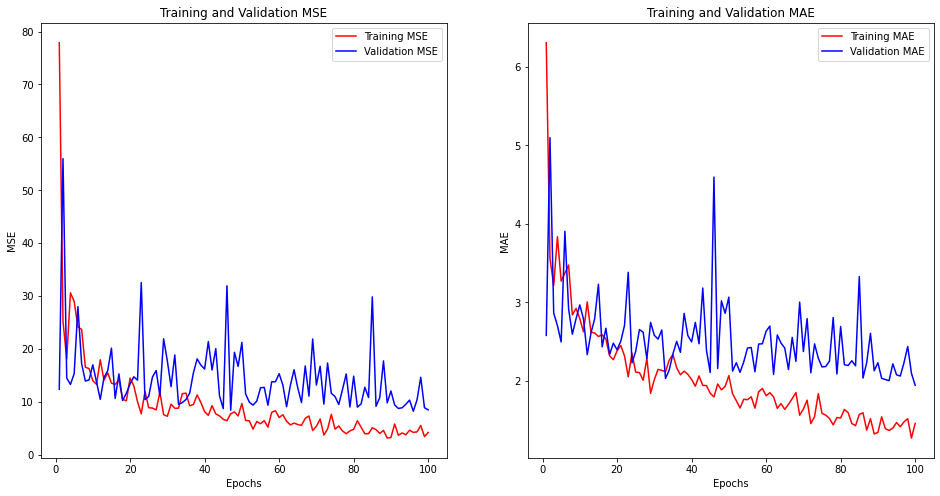

In [40]:
# IMPLEMENTE SEUS MODELOS AQUI --> QUESTÃO 5 (use várias células)

def build_model( n_inputs, n_outputs ):#Define uma função para construir um modelo ao qual n_inputs conta a quantd de caracter
    '''construção do modelo de rede neural convolucional'''
    
    rede = Sequential()#Cria um modelo de sequencia
    rede.add( Dense(units = 128, activation = "relu", input_shape = (n_inputs,)))
    #Responsável por adcionar camadas com a função Dense, usando 128 como número de campadas, usando a ativação Relu e a contagem
    # de caracteres do BD
    
    rede.add(Dense(units = 128, activation = "relu"))
    #Aplica o Dense com 128 neuronios definido por camada e também a ativação pelo o Relu
    
    rede.add(Dense(units = n_outputs ))
    #Função Dense adicionada sem um número padrão e a função de Nsaídas.
    return rede#retorna os resultados obtido
model = build_model(13, 1)
model.compile( optimizer = SGD(learning_rate = 0.001, momentum = 0.0), loss = "mse", metrics = ["mae"] )
model.summary()

hist = model.fit(x = train_data, y = train_targets, epochs = 100, 
                 batch_size = 1, validation_data = ( val_data, val_targets ), 
                 verbose = 1)

# plotando os resultados obtidos
fig, axes = plt.subplots(1, 2, squeeze = False, figsize = (16,8))

history_dict = hist.history

# loss - MSE
train_loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

# epochs
epochs = range(1, len(train_loss_values) + 1)

# metrica - MAE
train_mae_values = history_dict["mae"]
val_mae_values = history_dict["val_mae"]

ax = axes.flat[0]
ax.plot(epochs, train_loss_values, "r", label = "Training MSE")
ax.plot(epochs, val_loss_values, "b", label = "Validation MSE")
ax.set_title("Training and Validation MSE")
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE")
ax.legend()

ax = axes.flat[1]
ax.plot(epochs, train_mae_values, "r", label = "Training MAE")
ax.plot(epochs, val_mae_values, "b", label = "Validation MAE")
ax.set_title("Training and Validation MAE")
ax.set_xlabel("Epochs")
ax.set_ylabel("MAE")
ax.legend()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_30 (Dense)            (None, 32)                448       
                                                                 
 dense_31 (Dense)            (None, 32)                1056      
                                                                 
 dense_32 (Dense)            (None, 1)                 33        
                                                                 
Total params: 1,537
Trainable params: 1,537
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
302/302 [==============================] - 1s 996us/step - loss: 96.2884 - mae: 7.2991 - val_loss: 41.1204 - val_mae: 4.1149
Epoch 2/100
302/302 [==============================] - 0s 751us/step - loss: 49.1541 - mae: 4.8143 - val_loss: 36.3270 - val_mae: 4.8652
Epoch 3/100
302/302 [====================

Epoch 55/100
302/302 [==============================] - 0s 736us/step - loss: 6.7412 - mae: 2.0031 - val_loss: 17.5843 - val_mae: 2.5964
Epoch 56/100
302/302 [==============================] - 0s 752us/step - loss: 6.9120 - mae: 1.9789 - val_loss: 19.5139 - val_mae: 2.7919
Epoch 57/100
302/302 [==============================] - 0s 718us/step - loss: 6.9016 - mae: 2.0400 - val_loss: 19.4383 - val_mae: 2.6560
Epoch 58/100
302/302 [==============================] - 0s 756us/step - loss: 6.7787 - mae: 2.0194 - val_loss: 15.9045 - val_mae: 2.5584
Epoch 59/100
302/302 [==============================] - 0s 801us/step - loss: 6.8745 - mae: 2.0586 - val_loss: 15.9297 - val_mae: 2.5297
Epoch 60/100
302/302 [==============================] - 0s 715us/step - loss: 6.6429 - mae: 1.9999 - val_loss: 16.0525 - val_mae: 2.6150
Epoch 61/100
302/302 [==============================] - 0s 699us/step - loss: 6.5828 - mae: 2.0189 - val_loss: 16.6765 - val_mae: 2.5364
Epoch 62/100
302/302 [===================

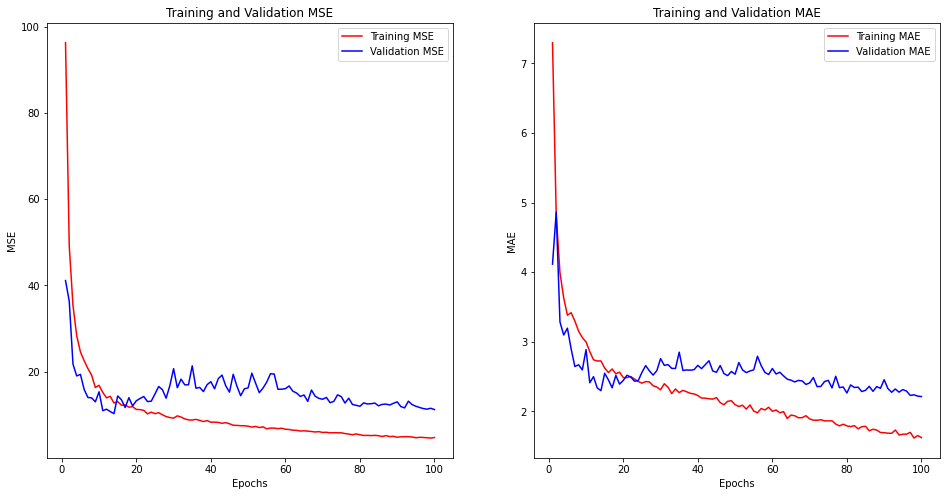

In [43]:
# IMPLEMENTE SEUS MODELOS AQUI --> QUESTÃO 5 (use várias células)

def build_model( n_inputs, n_outputs ):#Define uma função para construir um modelo ao qual n_inputs conta a quantd de caracter
    '''construção do modelo de rede neural convolucional'''
    
    rede = Sequential()#Cria um modelo de sequencia
    rede.add( Dense(units = 32, activation = "sigmoid", input_shape = (n_inputs,)))
    #Responsável por adcionar camadas com a função Dense, usando 64 como número de campadas, usando a ativação Sigmoid e a contagem
    # de caracteres do BD
    
    rede.add(Dense(units = 32, activation = "sigmoid"))
    #Aplica o Dense com 64 neuronios definido por camada e também a ativação pelo o Sigmoid
    
    rede.add(Dense(units = n_outputs ))
    #Função Dense adicionada sem um número padrão e a função de Nsaídas.
    return rede#retorna os resultados obtido
model = build_model(13, 1)
model.compile( optimizer = SGD(learning_rate = 0.001, momentum = 0.0), loss = "mse", metrics = ["mae"] )
model.summary()

hist = model.fit(x = train_data, y = train_targets, epochs = 100, 
                 batch_size = 1, validation_data = ( val_data, val_targets ), 
                 verbose = 1)

# plotando os resultados obtidos
fig, axes = plt.subplots(1, 2, squeeze = False, figsize = (16,8))

history_dict = hist.history

# loss - MSE
train_loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

# epochs
epochs = range(1, len(train_loss_values) + 1)

# metrica - MAE
train_mae_values = history_dict["mae"]
val_mae_values = history_dict["val_mae"]

ax = axes.flat[0]
ax.plot(epochs, train_loss_values, "r", label = "Training MSE")
ax.plot(epochs, val_loss_values, "b", label = "Validation MSE")
ax.set_title("Training and Validation MSE")
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE")
ax.legend()

ax = axes.flat[1]
ax.plot(epochs, train_mae_values, "r", label = "Training MAE")
ax.plot(epochs, val_mae_values, "b", label = "Validation MAE")
ax.set_title("Training and Validation MAE")
ax.set_xlabel("Epochs")
ax.set_ylabel("MAE")
ax.legend()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_33 (Dense)            (None, 128)               1792      
                                                                 
 dense_34 (Dense)            (None, 128)               16512     
                                                                 
 dense_35 (Dense)            (None, 1)                 129       
                                                                 
Total params: 18,433
Trainable params: 18,433
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
302/302 [==============================] - 0s 977us/step - loss: 88.1326 - mae: 6.8572 - val_loss: 57.8372 - val_mae: 6.5332
Epoch 2/100
302/302 [==============================] - 0s 739us/step - loss: 48.9534 - mae: 4.8124 - val_loss: 24.9437 - val_mae: 3.5463
Epoch 3/100
302/302 [==================

302/302 [==============================] - 0s 811us/step - loss: 9.7350 - mae: 2.3773 - val_loss: 17.2831 - val_mae: 2.7085
Epoch 55/100
302/302 [==============================] - 0s 791us/step - loss: 9.5482 - mae: 2.3637 - val_loss: 24.2594 - val_mae: 3.1286
Epoch 56/100
302/302 [==============================] - 0s 806us/step - loss: 9.3044 - mae: 2.3828 - val_loss: 17.7062 - val_mae: 2.6995
Epoch 57/100
302/302 [==============================] - 0s 789us/step - loss: 9.5297 - mae: 2.3431 - val_loss: 17.3474 - val_mae: 2.7312
Epoch 58/100
302/302 [==============================] - 0s 794us/step - loss: 9.7527 - mae: 2.3919 - val_loss: 18.5164 - val_mae: 2.7313
Epoch 59/100
302/302 [==============================] - 0s 796us/step - loss: 9.3641 - mae: 2.3510 - val_loss: 22.9991 - val_mae: 2.8829
Epoch 60/100
302/302 [==============================] - 0s 788us/step - loss: 9.3432 - mae: 2.3798 - val_loss: 20.4077 - val_mae: 2.8338
Epoch 61/100
302/302 [==============================] 

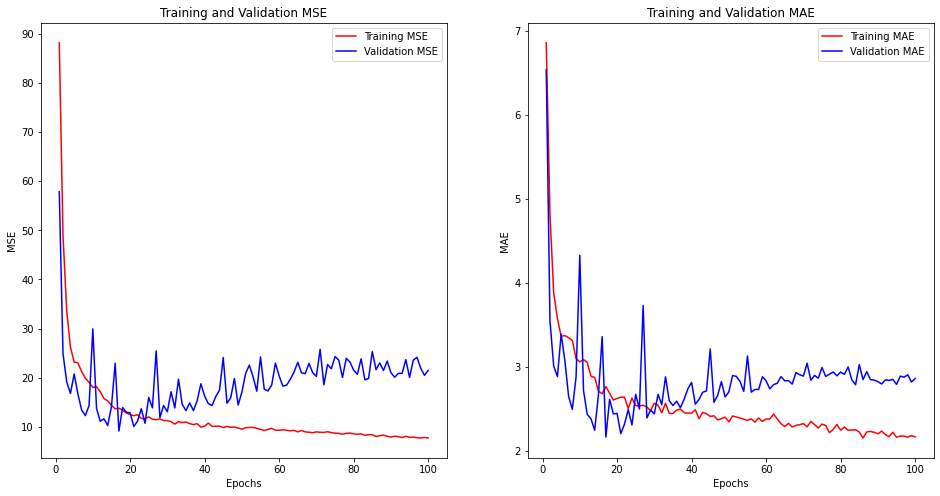

In [44]:
# IMPLEMENTE SEUS MODELOS AQUI --> QUESTÃO 5 (use várias células)

def build_model( n_inputs, n_outputs ):#Define uma função para construir um modelo ao qual n_inputs conta a quantd de caracter
    '''construção do modelo de rede neural convolucional'''
    
    rede = Sequential()#Cria um modelo de sequencia
    rede.add( Dense(units = 128, activation = "sigmoid", input_shape = (n_inputs,)))
    #Responsável por adcionar camadas com a função Dense, usando 128 como número de campadas, usando a ativação Relu e a contagem
    # de caracteres do BD
    
    rede.add(Dense(units = 128, activation = "sigmoid"))
    #Aplica o Dense com 128 neuronios definido por camada e também a ativação pelo o Relu
    
    rede.add(Dense(units = n_outputs ))
    #Função Dense adicionada sem um número padrão e a função de Nsaídas.
    return rede#retorna os resultados obtido
model = build_model(13, 1)
model.compile( optimizer = SGD(learning_rate = 0.001, momentum = 0.0), loss = "mse", metrics = ["mae"] )
model.summary()

hist = model.fit(x = train_data, y = train_targets, epochs = 100, 
                 batch_size = 1, validation_data = ( val_data, val_targets ), 
                 verbose = 1)

# plotando os resultados obtidos
fig, axes = plt.subplots(1, 2, squeeze = False, figsize = (16,8))

history_dict = hist.history

# loss - MSE
train_loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

# epochs
epochs = range(1, len(train_loss_values) + 1)

# metrica - MAE
train_mae_values = history_dict["mae"]
val_mae_values = history_dict["val_mae"]

ax = axes.flat[0]
ax.plot(epochs, train_loss_values, "r", label = "Training MSE")
ax.plot(epochs, val_loss_values, "b", label = "Validation MSE")
ax.set_title("Training and Validation MSE")
ax.set_xlabel("Epochs")
ax.set_ylabel("MSE")
ax.legend()

ax = axes.flat[1]
ax.plot(epochs, train_mae_values, "r", label = "Training MAE")
ax.plot(epochs, val_mae_values, "b", label = "Validation MAE")
ax.set_title("Training and Validation MAE")
ax.set_xlabel("Epochs")
ax.set_ylabel("MAE")
ax.legend()

## <span style='color:green'>Respostas da Questão 5:</span>

* Diminuindo o número de neurônio para 32 com a ativação relu: Ao efetuar apenas a mudança no seu número de neurônio efetuamos, também uma dimunição da qualidade de processamento.
  
  Aumentando o número de neurônio para 128 com a ativação relu: Ao efetuar apenas a mudança no seu número de neurônio efetuamos, também uma aumento da qualidade de processamento.
  
  Diminuindo o número de neurônio para 32 com a ativação Sigmoid: Além de efetuar a diminução da qualidade de processamento,  usando a sigmoid teremos:para valores pequenos (<-5), sigmoid retorna um valor próximo a zero, e para valores grandes (>5) o resultado da função fica próximo de 1.
  
  Aumentando o número de neurônio para 128 com a ativação Sigmoid: Além de efetuar o aumento da qualidade de processamento,  usando a sigmoid teremos:para valores pequenos (<-5), sigmoid retorna um valor próximo a zero, e para valores grandes (>5) o resultado da função fica próximo de 1.
  
  Obs: Efetuei da forma acima, para que através dos gráficos possamos ver o funcionamento tanto das diminuições de densidades, cmo também a aplicação de outras formas de ativação e seus comportamento demonstrado nos gráficos!
  

### Teste do modelo

O teste do modelo pode ser realizado a partir da função **evaluate**, que recebe os dados de treino e retorna o valor de loss calculado para esse conjunto e os valores de cada métrica da lista fornecida durante a compilação do modelo. 

* É uma prática comum realizar ajustes no modelo com base no conjunto de validação e só utilizar o conjunto de testes após a definição dos hiperparâmetros definitivos.
* Como os hiperparâmetros são ajustados a partir dos resultados obtidos para o conjunto de validação, o modelo pode acabar. sobreajustando aos dados de validação, então é interessante mudar os dados desse conjunto com frequência.
* Para mudar os dados de validação basta alterar a semente na função train_test_split.
* Crie um novo modelo do zero após a realização de mudanças nos conjuntos de treino/validação.

In [45]:
test_mse, test_mae = model.evaluate( test_data, test_targets)

# observa-se que os dados de saída são normalizados em milhares de dólares, 
# então é necessário multiplicar por 1000 para obter os valores absolutos
print("Erro médio absoluto de teste: ${:.2f}".format(1000*test_mae))

4/4 [==============================] - 0s 2ms/step - loss: 27.7891 - mae: 3.3653
Erro médio absoluto de teste: $3365.28


## <span style='color:blue'>Questão 6: [Valor da Questão: 1.0][Taxa de acerto: x.x]</span>

* Verifique novamente a faixa de valores dos gabaritos no banco de dados. Considerando a extensão dessa faixa de valores, pode-se dizer que as predições do modelo são significativas?

In [46]:
# IMPLEMENTE SEU CÓDIGO AQUI --> QUESTÃO 6
# IMPLEMENTE SEU CÓDIGO AQUI -QUESTÃO 1 - letra (c)

Gabtrain = train_targets
Gabtest = test_targets

print("Dados de Gabarito de Treinamento!")
print("Dimensão dos rótulos dos Dados para Treinamento: ", Gabtrain.shape)
print("Menor valor do Gabarito de Treinamento:", (np.min(Gabtrain, axis = 0)))
print("\nMaior valor do Gabarito de Treinamento:", (np.max(Gabtrain, axis = 0)))
print("\nValor Médio do Gabarito de Treinamento:", (np.mean(Gabtrain, axis = 0)))
print("\nValor de Variação do Gabarito de Treinamento:", (np.var(Gabtrain, axis = 0)))

print("\n===========================================\n")

print("Dados de Gabarito de Teste!")
print("Dimensão dos rótulos dos Dados para Teste: ", Gabtest.shape)
print("Menor valor do Gabarito de Teste:", (np.min(Gabtest, axis = 0)))
print("\nMaior valor do Gabarito de Teste:", (np.max(Gabtest, axis = 0)))
print("\nValor Médio do Gabarito de Teste:", (np.mean(Gabtest, axis = 0)))
print("\nValor de Variação do Gabarito de Teste:", (np.var(Gabtest, axis = 0)))


Dados de Gabarito de Treinamento!
Dimensão dos rótulos dos Dados para Treinamento:  (302,)
Menor valor do Gabarito de Treinamento: 5.0

Maior valor do Gabarito de Treinamento: 50.0

Valor Médio do Gabarito de Treinamento: 22.868543046357615

Valor de Variação do Gabarito de Treinamento: 90.36414291039866


Dados de Gabarito de Teste!
Dimensão dos rótulos dos Dados para Teste:  (102,)
Menor valor do Gabarito de Teste: 5.6

Maior valor do Gabarito de Teste: 50.0

Valor Médio do Gabarito de Teste: 23.07843137254902

Valor de Variação do Gabarito de Teste: 83.24384851980008


## <span style='color:green'>Resposta da Questão 6:</span>

* Sim, já é possível fazer a utilização das predições feitas pelo o gabarito, apesar de possuir valores que estão fora de faixa, mas existem mais resultados que estão na faixa, gerando um indice de acertibilidade considerável, que deve ser melhorado para a empregação que for ser utilizado o modelo.

### Referências
* Chollet, Francois. Deep learning with Python. Simon and Schuster, 2017.

![gif3](https://user-images.githubusercontent.com/58775072/142712798-3c5ce76c-8d6f-4345-8d65-2be3f7aa2ae9.gif)